In [29]:
import os
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

import torchvision
from torchvision import datasets, transforms

print(os.listdir("/kaggle/input"))

dataset_path = "/kaggle/input/datasets"
print(os.listdir(dataset_path))

['datasets']
['msambare']


In [30]:
train_transform = transforms.Compose([
    transforms.Grayscale(),
    transforms.Resize((48, 48)),
    transforms.RandomHorizontalFlip(p=0.5),     
    transforms.RandomRotation(degrees=15),       
    transforms.ColorJitter(brightness=0.2),      
    transforms.ToTensor(),
])

train_dataset = datasets.ImageFolder(
    root="/kaggle/input/datasets/msambare/fer2013/train",
    transform=train_transform
)

print(len(train_dataset))

28709


In [31]:
from torch.utils.data import DataLoader, Subset
import os


test_transform = transforms.Compose([
    transforms.Grayscale(),
    transforms.Resize((48, 48)),
    transforms.ToTensor(),
])

mixed_test_dataset = datasets.ImageFolder(root='/kaggle/input/datasets/msambare/fer2013/test', transform=test_transform) 

val_indices = []
test_indices = []

for idx, (path, label) in enumerate(mixed_test_dataset.samples):
    filename = os.path.basename(path) 
    
    if filename.startswith('PublicTest'):
        val_indices.append(idx)
    elif filename.startswith('PrivateTest'):
        test_indices.append(idx)

val_dataset = Subset(mixed_test_dataset, val_indices)
true_test_dataset = Subset(mixed_test_dataset, test_indices)

print(len(val_dataset))
print(len(true_test_dataset))
test_dataset = true_test_dataset

3589
3589


In [32]:
image, label = train_dataset[0]

print(image.shape)
print(label)

torch.Size([1, 48, 48])
0


['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


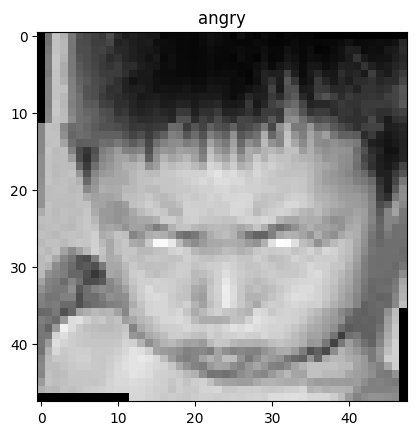

In [33]:
print(train_dataset.classes)
emotion = train_dataset.classes[label]
plt.imshow(image.squeeze(), cmap='gray')
plt.title(emotion)
plt.show()

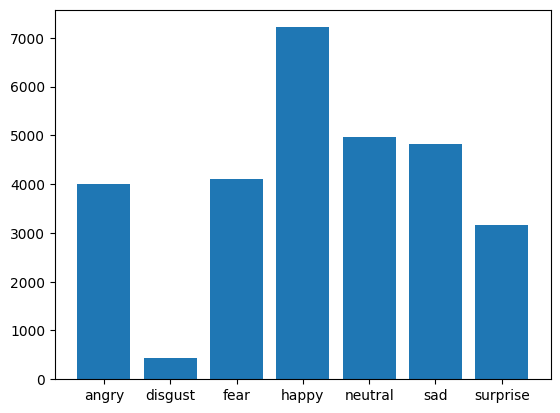

In [34]:
train_count = {name: train_dataset.targets.count(i) for i, name in enumerate(train_dataset.classes)}

plt.bar(train_count.keys(), train_count.values())
plt.show()

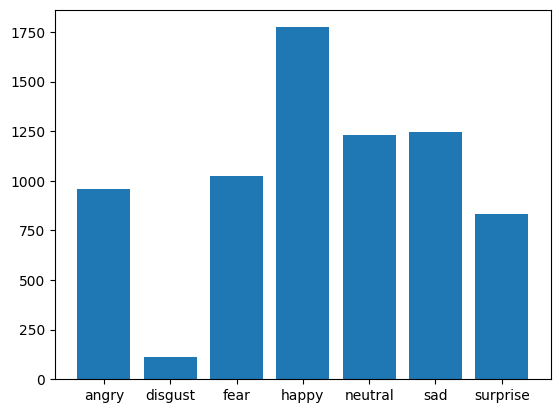

In [35]:
test_count = {name: mixed_test_dataset.targets.count(i) for i, name in enumerate(mixed_test_dataset.classes)}

plt.bar(test_count.keys(), test_count.values())
plt.show()

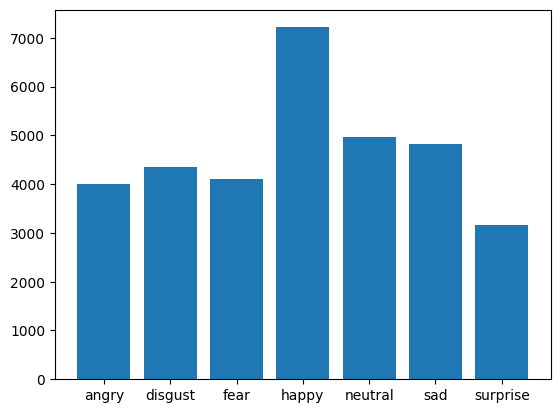

In [36]:
disgust1 = train_dataset.class_to_idx['disgust']
disgustsamples = [sample for sample in train_dataset.samples if sample[1] == disgust1]
replication_factor = 9
for _ in range(replication_factor):
    train_dataset.samples.extend(disgustsamples)

train_dataset.targets = [sample[1] for sample in train_dataset.samples]

train_count = {name: train_dataset.targets.count(i) for i, name in enumerate(train_dataset.classes)}
plt.bar(train_count.keys(), train_count.values())
plt.show()

In [37]:
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True 
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=64, 
    shuffle=False
)

test_loader = DataLoader(
    test_dataset, 
    batch_size=64, 
    shuffle=False
)

print(f"Total training batches: {len(train_loader)}")
print(f"Total testing batches: {len(test_loader)}")
print(f"Total validation batches: {len(val_loader)}")

Total training batches: 510
Total testing batches: 57
Total validation batches: 57


In [38]:
labels = next(iter(train_loader))[1]
unique_classes, counts = torch.unique(labels, return_counts=True)
print(dict(zip(unique_classes.tolist(), counts.tolist())))

{0: 12, 1: 7, 2: 8, 3: 13, 4: 8, 5: 7, 6: 9}


In [39]:
import torch.nn as nn
import torch.nn.functional as F

class CustomEmotionCNN(nn.Module):
    def __init__(self):
        super(CustomEmotionCNN, self).__init__()
        
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.conv5 = nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1)
        self.conv6 = nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)
        self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.fc1 = nn.Linear(2304, 512)
        self.drop1 = nn.Dropout(0.5)
        
        self.fc2 = nn.Linear(512, 128)
        self.drop2 = nn.Dropout(0.5)
        
        self.fc3 = nn.Linear(128, 7)
        
    def forward(self, x):
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))
        
        x = F.relu(self.conv3(x))
        x = self.pool3(F.relu(self.bn3(self.conv4(x))))
        

        x = F.relu(self.conv5(x))
        x = self.pool4(F.relu(self.bn4(self.conv6(x))))
        
        x = x.view(x.size(0), -1)
        
        x = F.relu(self.fc1(x))
        x = self.drop1(x)
        
        x = F.relu(self.fc2(x))
        x = self.drop2(x)
        
        x = self.fc3(x)
        
        return x

if __name__ == "__main__":
    import torch
    model = CustomEmotionCNN()
    dummy_input = torch.randn(64, 1, 48, 48) 
    output = model(dummy_input)
    print(f"Output shape: {output.shape}") 

Output shape: torch.Size([64, 7])


In [40]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

In [41]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = model.to(device)

Using device: cuda


In [42]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Total Parameters: {total_params}")

Total Parameters: 2373191


In [44]:
import torch

EPOCHS = 40
train_losses = []
val_losses = []
val_accuracies = []

print("Starting Training Loop...")

for epoch in range(EPOCHS):
    
    model.train() 
    running_train_loss = 0.0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        
        outputs = model(images)
        
        loss = criterion(outputs, labels)
        
        loss.backward()
        
        optimizer.step()
        
        running_train_loss += loss.item()
    avg_train_loss = running_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    #VALIDATION PHASE

    model.eval()
    running_val_loss = 0.0
    correct_predictions = 0
    total_predictions = 0
    
    with torch.no_grad(): 
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_val_loss += loss.item()
            
            _, predicted = torch.max(outputs, 1)
            total_predictions += labels.size(0)
            correct_predictions += (predicted == labels).sum().item()
            
    avg_val_loss = running_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    
    val_acc = (correct_predictions / total_predictions) * 100
    val_accuracies.append(val_acc)
    
    scheduler.step(avg_val_loss)
    
    print(f"Epoch [{epoch+1}/{EPOCHS}] | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.2f}%")

print("Training Complete!")

Starting Training Loop...
Epoch [1/40] | Train Loss: 1.7590 | Val Loss: 1.6672 | Val Acc: 36.92%
Epoch [2/40] | Train Loss: 1.6159 | Val Loss: 1.5464 | Val Acc: 36.56%
Epoch [3/40] | Train Loss: 1.5099 | Val Loss: 1.4693 | Val Acc: 41.40%
Epoch [4/40] | Train Loss: 1.4130 | Val Loss: 1.3828 | Val Acc: 45.47%
Epoch [5/40] | Train Loss: 1.3439 | Val Loss: 1.3352 | Val Acc: 47.00%
Epoch [6/40] | Train Loss: 1.2876 | Val Loss: 1.3265 | Val Acc: 47.51%
Epoch [7/40] | Train Loss: 1.2378 | Val Loss: 1.2347 | Val Acc: 53.13%
Epoch [8/40] | Train Loss: 1.2010 | Val Loss: 1.1846 | Val Acc: 53.69%
Epoch [9/40] | Train Loss: 1.1551 | Val Loss: 1.1923 | Val Acc: 52.61%
Epoch [10/40] | Train Loss: 1.1277 | Val Loss: 1.1786 | Val Acc: 55.14%
Epoch [11/40] | Train Loss: 1.1026 | Val Loss: 1.1637 | Val Acc: 53.50%
Epoch [12/40] | Train Loss: 1.0833 | Val Loss: 1.1709 | Val Acc: 54.03%
Epoch [13/40] | Train Loss: 1.0649 | Val Loss: 1.1571 | Val Acc: 56.39%
Epoch [14/40] | Train Loss: 1.0329 | Val Loss: 

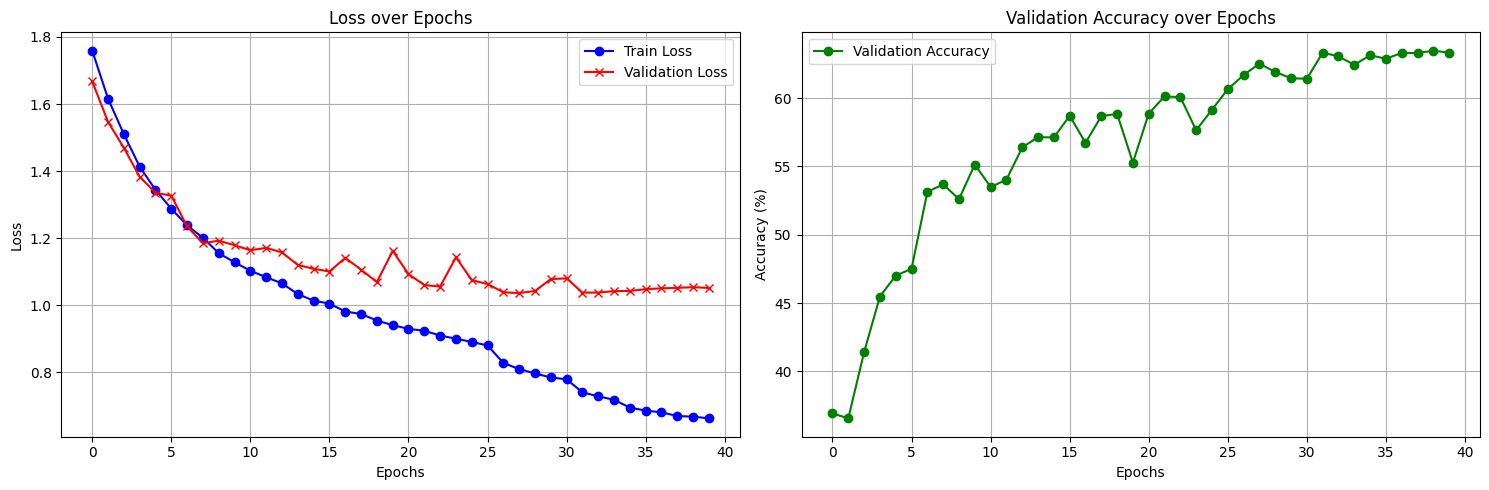

In [47]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(train_losses, label='Train Loss', color='blue', marker='o')
ax1.plot(val_losses, label='Validation Loss', color='red', marker='x')
ax1.set_title('Loss over Epochs')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

ax2.plot(val_accuracies, label='Validation Accuracy', color='green', marker='o')
ax2.set_title('Validation Accuracy over Epochs')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

Predictions for the Confusion Matrix


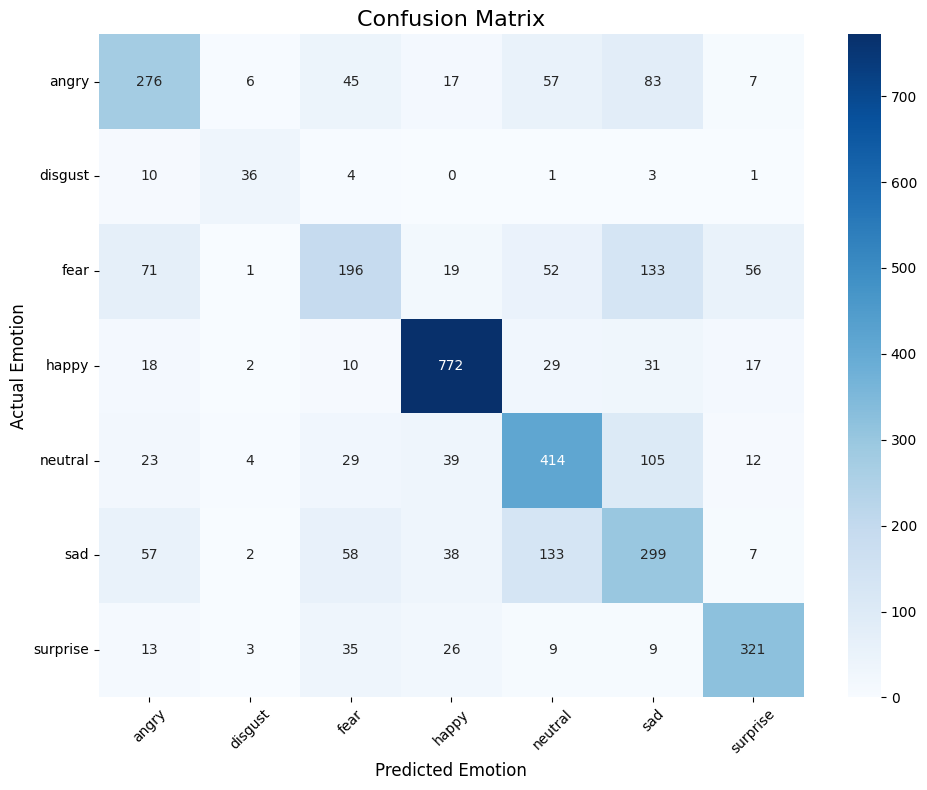

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

print("Predictions for the Confusion Matrix")

all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predictions = torch.max(outputs, 1)
        
        all_preds.extend(predictions.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))

emotion_names = train_dataset.classes 

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=emotion_names, 
            yticklabels=emotion_names)

plt.title('Confusion Matrix', fontsize=16)
plt.ylabel('Actual Emotion', fontsize=12)
plt.xlabel('Predicted Emotion', fontsize=12)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [49]:
import torch

# 1. Safety first: Turn off Dropout and BatchNorm updates
model.eval() 

correct_predictions = 0
total_predictions = 0
running_test_loss = 0.0

class_correct = [0] * 7
class_total = [0] * 7
emotion_classes = mixed_test_dataset.classes 

print("Running final evaluation on the true PrivateTest dataset...")

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        
        outputs = model(images)
        loss = criterion(outputs, labels)
        running_test_loss += loss.item()
        
        _, predicted = torch.max(outputs, 1)
        
        total_predictions += labels.size(0)
        correct_predictions += (predicted == labels).sum().item()
        
        correct_tensor = (predicted == labels).squeeze()
        for i in range(len(labels)):
            label = labels[i]
            class_correct[label] += correct_tensor[i].item()
            class_total[label] += 1

final_test_loss = running_test_loss / len(test_loader)
final_test_acc = (correct_predictions / total_predictions) * 100

print("\n" + "="*30)
print("🏆 FINAL MODEL RESULTS 🏆")
print("="*30)
print(f"Overall Test Loss:     {final_test_loss:.4f}")
print(f"Overall Test Accuracy: {final_test_acc:.2f}%\n")

print("--- ACCURACY PER EMOTION ---")
for i in range(7):
    if class_total[i] > 0:
        accuracy = 100 * class_correct[i] / class_total[i]
        print(f"{emotion_classes[i].capitalize().ljust(10)}: {accuracy:.1f}%")

Running final evaluation on the true PrivateTest dataset...

🏆 FINAL MODEL RESULTS 🏆
Overall Test Loss:     1.0053
Overall Test Accuracy: 64.47%

--- ACCURACY PER EMOTION ---
Angry     : 56.2%
Disgust   : 65.5%
Fear      : 37.1%
Happy     : 87.8%
Neutral   : 66.1%
Sad       : 50.3%
Surprise  : 77.2%


In [50]:
torch.save(model.state_dict(), 'emotion_model1.pth')
